✅ Kaggle credentials set

✅ Dataset ready | Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  angry       : train=3,995  test= 958
  disgust     : train=  436  test= 111
  fear        : train=4,097  test=1,024
  happy       : train=7,215  test=1,774
  neutral     : train=4,965  test=1,233
  sad         : train=4,830  test=1,247
  surprise    : train=3,171  test= 831
Device: cuda

Split summary:
  Train : 28,709  (full train folder)
  Val   : 3,589  (50% of test folder, seed=42)
  Test  : 3,589  (50% of test folder, seed=42)
Class weights: [1.027 9.407 1.001 0.568 0.826 0.849 1.293]

MLP wider_deeper | Parameters: 7,484,423
Architecture    : 2304 → 2048 → 1024 → 512 → 256 → 7
Dropout         : 0.35 → 0.30 → 0.25 → 0.20
lr=0.001  wd=5e-05  batch=128  warmup=5ep+cosine  max_ep=100  patience=10

  Ep          LR   Tr Loss   Tr Acc   Va Loss   Va Acc   Te Acc
──────────────────────────────────────────────────────────────────────────
   1    3.60e-04    2.1257   

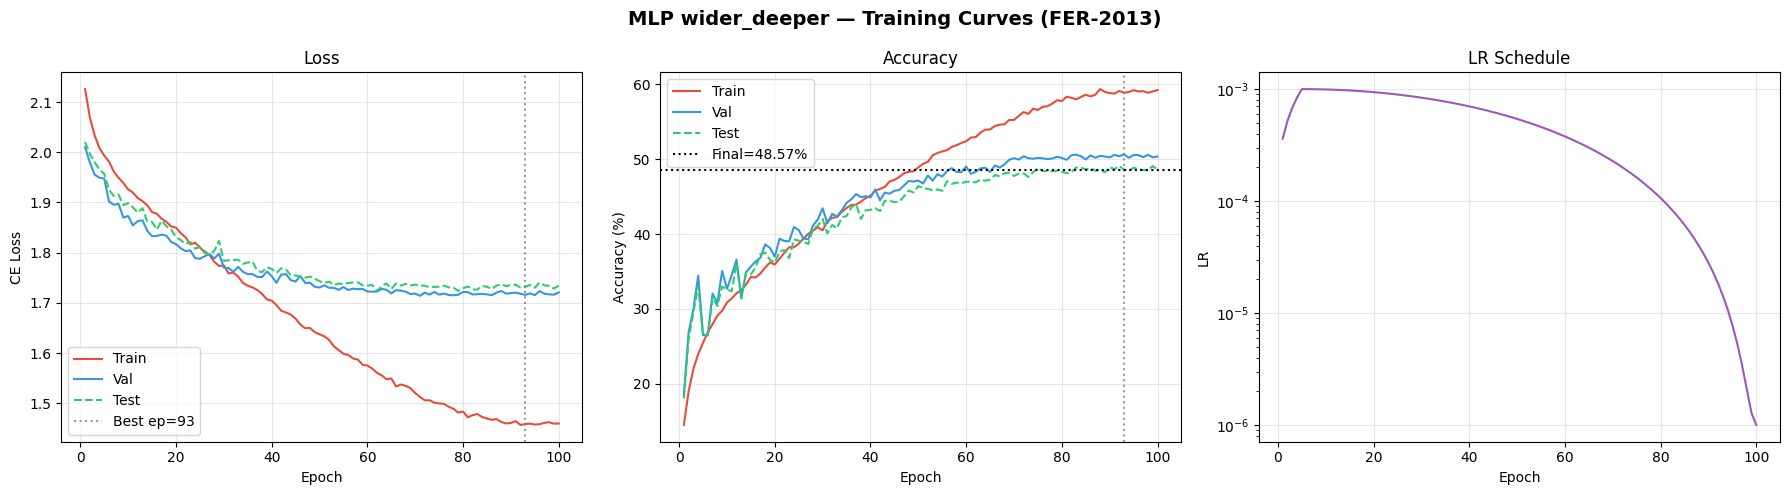

Saved: mlp_training_curves.png


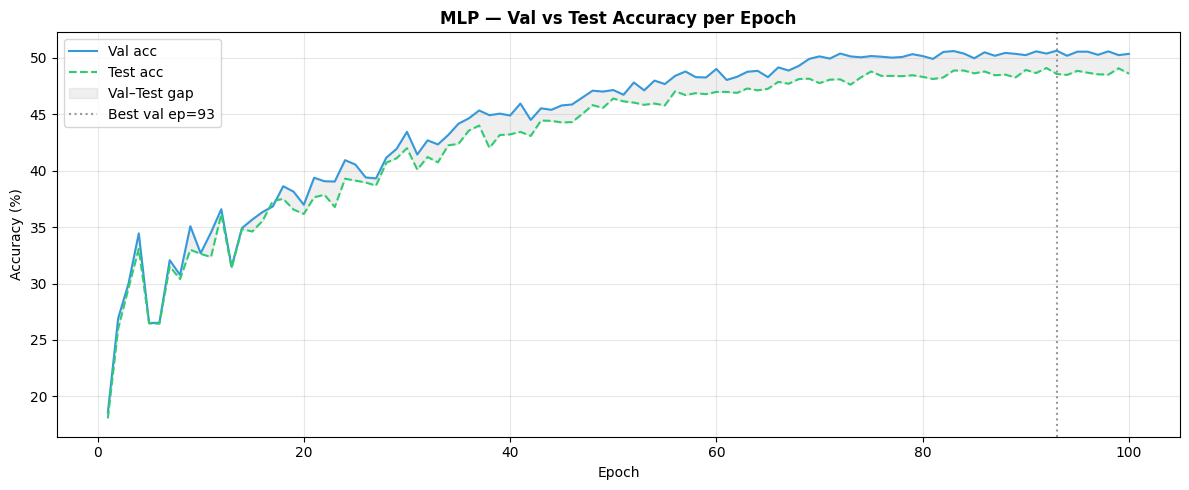

Saved: mlp_val_vs_test.png


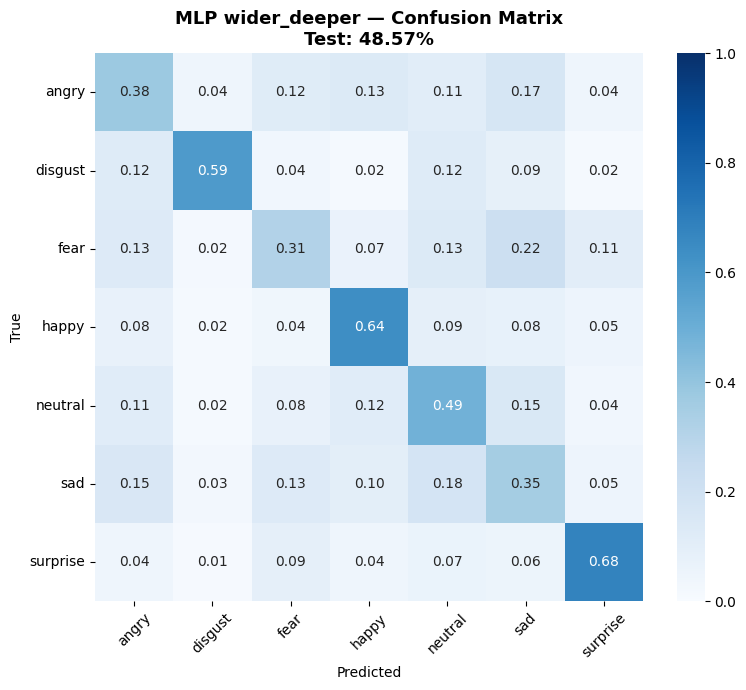

Saved: mlp_confusion_matrix.png


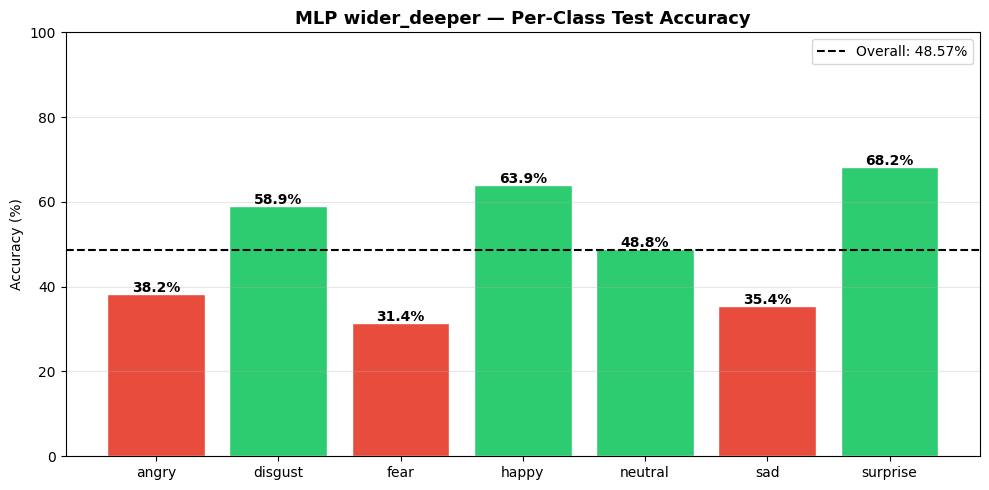

Saved: mlp_perclass_accuracy.png

✅ All MLP outputs saved to /content/


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  FER-2013 — MLP Best Config (wider_deeper)                      ║
# ║  Architecture : [2048, 1024, 512, 256]                          ║
# ║  Split        : Full train / test→50% val + 50% test            ║
# ║  Course       : Machine Learning, IGP-TUBS, Dr.-Ing. Maboudi    ║
# ╚══════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════
# CELL 1: Install + Kaggle credentials
# ═══════════════════════════════════════════════════════════
import os, json, subprocess, sys
from pathlib import Path

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])
kdir = os.path.expanduser("~/.kaggle")
os.makedirs(kdir, exist_ok=True)
with open(f"{kdir}/kaggle.json", "w") as f:
    json.dump({"username": "patilatharv",
               "key": "KGAT_6e476fff7b1550b8bc35669407cea260"}, f)
os.chmod(f"{kdir}/kaggle.json", 0o600)
print("✅ Kaggle credentials set")

# ═══════════════════════════════════════════════════════════
# CELL 2: Download FER-2013
# ═══════════════════════════════════════════════════════════
DATA_ROOT = Path("/content/fer2013")
subprocess.run([
    "kaggle", "datasets", "download",
    "-d", "msambare/fer2013",
    "--unzip", "-p", str(DATA_ROOT)
], check=True)

train_dir = DATA_ROOT / "train"
test_dir  = DATA_ROOT / "test"
classes   = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
print(f"\n✅ Dataset ready | Classes: {classes}")
for cls in classes:
    n_tr = len(list((train_dir / cls).glob("*.jpg")))
    n_te = len(list((test_dir  / cls).glob("*.jpg")))
    print(f"  {cls:12s}: train={n_tr:5,}  test={n_te:4,}")

# ═══════════════════════════════════════════════════════════
# CELL 3: Imports
# ═══════════════════════════════════════════════════════════
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import torchvision.transforms as T
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import copy, time, json as _json

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ═══════════════════════════════════════════════════════════
# CELL 4: DataLoaders
# Full train folder → training (no samples removed)
# Test folder → 50% val / 50% test (random_split, seeded)
# ═══════════════════════════════════════════════════════════
EMOTIONS   = ['angry','disgust','fear','happy','neutral','sad','surprise']
SEED       = 42
BATCH_SIZE = 128

transform_train = T.Compose([
    T.Grayscale(),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])
transform_test = T.Compose([
    T.Grayscale(),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])

# Full training set
train_ds  = datasets.ImageFolder(str(train_dir), transform=transform_train)

# Split test 50/50 — both subsets share transform_test (no augmentation)
test_full = datasets.ImageFolder(str(test_dir), transform=transform_test)
n_val     = len(test_full) // 2
n_test    = len(test_full) - n_val
torch.manual_seed(SEED)
val_ds, test_ds = random_split(test_full, [n_val, n_test])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"\nSplit summary:")
print(f"  Train : {len(train_ds):,}  (full train folder)")
print(f"  Val   : {len(val_ds):,}  (50% of test folder, seed={SEED})")
print(f"  Test  : {len(test_ds):,}  (50% of test folder, seed={SEED})")

# Class weights from full training set
counts  = torch.zeros(7)
for _, lbl in train_ds:
    counts[lbl] += 1
weights = counts.sum() / (7 * counts)
print(f"Class weights: {weights.numpy().round(3)}")

# ═══════════════════════════════════════════════════════════
# CELL 5: MLP Architecture (wider_deeper — best config)
# ═══════════════════════════════════════════════════════════
class MLP(nn.Module):
    """
    wider_deeper MLP — best performing FER-2013 config.
    Input: (B, 1, 48, 48) → flatten → (B, 2304) → 7 classes
    Progressive dropout: deeper layers get less regularization
    """
    def __init__(self,
                 hidden=[2048, 1024, 512, 256],
                 dropout=[0.35, 0.30, 0.25, 0.20],
                 num_classes=7):
        super().__init__()
        layers, in_dim = [], 48 * 48
        for h, d in zip(hidden, dropout):
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(d)]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

torch.manual_seed(SEED)
model    = MLP().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nMLP wider_deeper | Parameters: {n_params:,}")
print(f"Architecture    : 2304 → 2048 → 1024 → 512 → 256 → 7")
print(f"Dropout         : 0.35 → 0.30 → 0.25 → 0.20")

# ═══════════════════════════════════════════════════════════
# CELL 6: Hyperparameters (tuned to reduce overfitting)
# ═══════════════════════════════════════════════════════════
LR        = 1e-3
WD        = 5e-5
MAX_EP    = 100    # reduced from 120 — plateau clear by ep70
WARMUP_EP = 5
PATIENCE  = 10     # reduced from 20 — less wasted post-plateau epochs

criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE), label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WD)
warmup    = LinearLR(optimizer, start_factor=0.2, end_factor=1.0, total_iters=WARMUP_EP)
cosine    = CosineAnnealingLR(optimizer, T_max=MAX_EP - WARMUP_EP, eta_min=1e-6)
scheduler = SequentialLR(optimizer, [warmup, cosine], milestones=[WARMUP_EP])

print(f"lr={LR}  wd={WD}  batch={BATCH_SIZE}  "
      f"warmup={WARMUP_EP}ep+cosine  max_ep={MAX_EP}  patience={PATIENCE}")

# ═══════════════════════════════════════════════════════════
# CELL 7: Training loop — val AND test tracked every epoch
# ═══════════════════════════════════════════════════════════
def evaluate_loader(loader):
    """Evaluate model on any loader — returns (loss, accuracy)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits       = model(imgs)
            total_loss  += criterion(logits, labels).item() * imgs.size(0)
            correct     += (logits.argmax(1) == labels).sum().item()
            total       += labels.size(0)
    return total_loss / total, correct / total

history = {
    'train_loss': [], 'val_loss': [],  'test_loss': [],
    'train_acc':  [], 'val_acc':  [],  'test_acc':  [],
    'lr': []
}

best_val_acc = 0.0
best_weights = None
patience_ctr = 0
best_epoch   = 0

print(f"\n{'Ep':>4}  {'LR':>10}  {'Tr Loss':>8}  {'Tr Acc':>7}  "
      f"{'Va Loss':>8}  {'Va Acc':>7}  {'Te Acc':>7}")
print("─" * 74)

t0 = time.time()

for epoch in range(1, MAX_EP + 1):

    # Train
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_loss    += loss.item() * imgs.size(0)
        tr_correct += (logits.argmax(1) == labels).sum().item()
        tr_total   += labels.size(0)

    scheduler.step()
    tr_loss /= tr_total
    tr_acc   = tr_correct / tr_total

    # Val + Test
    va_loss, va_acc = evaluate_loader(val_loader)
    te_loss, te_acc = evaluate_loader(test_loader)
    cur_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['test_loss'].append(te_loss);  history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc);     history['test_acc'].append(te_acc)
    history['lr'].append(cur_lr)

    star = ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_weights = copy.deepcopy(model.state_dict())
        patience_ctr = 0
        best_epoch   = epoch
        star = " ★"
    else:
        patience_ctr += 1

    print(f"{epoch:4d}  {cur_lr:10.2e}  {tr_loss:8.4f}  {tr_acc*100:6.2f}%  "
          f"{va_loss:8.4f}  {va_acc*100:6.2f}%  {te_acc*100:6.2f}%{star}")

    if patience_ctr >= PATIENCE:
        print(f"\n⏹  Early stop @ ep {epoch}  "
              f"(best val {best_val_acc*100:.2f}% @ ep {best_epoch})")
        break

elapsed = (time.time() - t0) / 60
print(f"\n✅ Done in {elapsed:.1f} min")
model.load_state_dict(best_weights)
torch.save(best_weights, "/content/mlp_wider_deeper_seed42_best.pt")
print("💾 Saved → mlp_wider_deeper_seed42_best.pt")

# ═══════════════════════════════════════════════════════════
# CELL 8: Final test evaluation at best checkpoint
# ═══════════════════════════════════════════════════════════
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.append(preds); all_labels.append(labels)

preds    = torch.cat(all_preds).numpy()
labels   = torch.cat(all_labels).numpy()
test_acc_final = (preds == labels).mean()
best_ep_test   = history['test_acc'][best_epoch - 1]

print(f"\nTest acc @ best val checkpoint (ep {best_epoch}): {best_ep_test*100:.2f}%")
print(f"Test acc (recomputed from checkpoint)           : {test_acc_final*100:.2f}%")
print(f"Best val acc                                    : {best_val_acc*100:.2f}%")
print(f"\nPer-class test accuracy:")
print(f"  {'Class':12s}  {'N':>5}  {'Acc':>6}")
print("─" * 35)

per_class_acc = []
for i, name in enumerate(EMOTIONS):
    mask = labels == i
    acc  = (preds[mask] == i).mean() if mask.sum() > 0 else 0.0
    flag = "⚠️ " if acc < 0.40 else "✅"
    per_class_acc.append(acc)
    print(f"  {name:12s}: {mask.sum():5d}  {acc*100:5.1f}%  {flag} {'█'*int(acc*25)}")

results = {
    "model": "MLP_wider_deeper", "seed": SEED,
    "split": "full_train / test_50val_50test",
    "test_acc_at_best_val_epoch": float(best_ep_test),
    "test_acc_final": float(test_acc_final),
    "best_val_acc": float(best_val_acc),
    "best_epoch": best_epoch,
    "per_class_acc": {EMOTIONS[i]: float(per_class_acc[i]) for i in range(7)},
    "history": history
}
with open("/content/mlp_results.json", "w") as f:
    _json.dump(results, f, indent=2)
print("\n💾 Results saved → mlp_results.json")

# ═══════════════════════════════════════════════════════════
# CELL 9: Visualizations
# ═══════════════════════════════════════════════════════════
ep_axis = range(1, len(history['train_loss']) + 1)

# Fig 1: Loss + Accuracy + LR (3 panels, all 3 splits)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MLP wider_deeper — Training Curves (FER-2013)', fontsize=14, fontweight='bold')

axes[0].plot(ep_axis, history['train_loss'], color='#e74c3c', label='Train', lw=1.5)
axes[0].plot(ep_axis, history['val_loss'],   color='#3498db', label='Val',   lw=1.5)
axes[0].plot(ep_axis, history['test_loss'],  color='#2ecc71', label='Test',  lw=1.5, ls='--')
axes[0].axvline(best_epoch, color='gray', ls=':', alpha=0.8, label=f'Best ep={best_epoch}')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_axis, [a*100 for a in history['train_acc']], color='#e74c3c', label='Train', lw=1.5)
axes[1].plot(ep_axis, [a*100 for a in history['val_acc']],   color='#3498db', label='Val',   lw=1.5)
axes[1].plot(ep_axis, [a*100 for a in history['test_acc']],  color='#2ecc71', label='Test',  lw=1.5, ls='--')
axes[1].axvline(best_epoch, color='gray', ls=':', alpha=0.8)
axes[1].axhline(test_acc_final*100, color='black', ls=':', lw=1.5, label=f'Final={test_acc_final*100:.2f}%')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep_axis, history['lr'], color='#9b59b6', lw=1.5)
axes[2].set_title('LR Schedule'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: mlp_training_curves.png")

# Fig 2: Val vs Test per epoch (generalization stability)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ep_axis, [a*100 for a in history['val_acc']],  color='#3498db', label='Val acc',  lw=1.5)
ax.plot(ep_axis, [a*100 for a in history['test_acc']], color='#2ecc71', label='Test acc', lw=1.5, ls='--')
ax.fill_between(ep_axis,
                [a*100 for a in history['val_acc']],
                [a*100 for a in history['test_acc']],
                alpha=0.12, color='gray', label='Val–Test gap')
ax.axvline(best_epoch, color='gray', ls=':', alpha=0.8, label=f'Best val ep={best_epoch}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('MLP — Val vs Test Accuracy per Epoch', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/mlp_val_vs_test.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: mlp_val_vs_test.png")

# Fig 3: Confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(labels, preds, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS,
            ax=ax, vmin=0, vmax=1, annot_kws={'size': 10})
ax.set_title(f'MLP wider_deeper — Confusion Matrix\nTest: {test_acc_final*100:.2f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=45); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('/content/mlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: mlp_confusion_matrix.png")

# Fig 4: Per-class bar
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if a >= 0.40 else '#e74c3c' for a in per_class_acc]
bars   = ax.bar(EMOTIONS, [a*100 for a in per_class_acc], color=colors, edgecolor='white')
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.axhline(test_acc_final*100, color='black', ls='--', lw=1.5,
           label=f'Overall: {test_acc_final*100:.2f}%')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 100)
ax.set_title('MLP wider_deeper — Per-Class Test Accuracy', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/mlp_perclass_accuracy.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved: mlp_perclass_accuracy.png")

print("\n✅ All MLP outputs saved to /content/")